#### : Harmful Content Detection

#### Objective
##### The objective of this module is to develop a machine learning model that automatically detects harmful content from user-generated text. The model classifies text into predefined harmful content categories, helping government organizations identify abusive, offensive, or unsafe content and take timely moderation actions.

#### Importance of This Module
Harmful Content Detection plays a vital role in maintaining a safe and respectful online environment. It enables government agencies and social media monitoring systems to detect toxic, abusive, hateful, or offensive content automatically, reducing the spread of harmful information and improving public trust in digital platforms.

#### Contribution to the Project
This module contributes to the Government Social Media Analytics project by identifying harmful user comments and classifying them into appropriate categories. The insights generated from this module support content moderation, citizen safety, policy enforcement, and faster decision-making for handling inappropriate online content.

#### Dataset Description

##### Dataset Name: harmful_content
This dataset contains user-generated text collected from online platforms along with corresponding harmful content labels. Each record consists of a text message and its associated category indicating whether the content is harmful or belongs to a specific harmful content class. The dataset is designed for supervised machine learning and text classification tasks.

#### Why this Dataset?
This dataset was selected because it contains labeled text samples suitable for harmful content classification. It provides real-world examples of user-generated content, making it useful for training machine learning models to automatically identify harmful or non-harmful text. The dataset supports Natural Language Processing (NLP) techniques and helps build an effective text classification system.

#### Features (X) and Target Variable (Y)
Input Feature (X)

The primary input feature used for model training is:

*text

The text column contains user-generated comments, posts, or messages that will be analyzed by the machine learning model.

#### Target Variable (Y)

The target variable is:
label

The label column represents the harmful content category assigned to each text. The machine learning model learns patterns from the text and predicts the correct harmful content class.

#### Machine Learning Problem Type

Problem Type: Text Classification

Since the target variable contains categories (labels) rather than numerical values, this module is a Supervised Machine Learning Classification problem.

## 1: Dataset Loading
## 2: Harmful Content Detection
## 3: Feature Engineering
## 4: Harmful Content Model Preparation (Train-Test Split)
## 5: Model Building
## 6: Model Evaluation
## 7: Model Comparison
## 8: Model Saving and Prediction
## 9: Project Conclusion
## 10: Final Project Conclusion and Future Scope

#### Load Dataset from MySQL

### step 1: Dataset Loading

In [ ]:
import pandas as pd
import numpy as np

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

In [ ]:
connection_url = URL.create(
    drivername="mysql+pymysql",
    username="root",
    password="MyNewPassword",
    host="localhost",
    port=3306,
    database="government_social_media"
)

engine = create_engine(connection_url)

print("✅ Connected Successfully")

In [ ]:
harmful_df = pd.read_sql(
    "SELECT * FROM harmful_content",
    engine
)

In [ ]:
print(harmful_df.shape)

In [ ]:
harmful_df.head()

In [ ]:
print(harmful_df.columns)

In [ ]:
harmful_df.info()

In [ ]:
harmful_df.isnull().sum()

In [ ]:
harmful_df.duplicated().sum()

In [ ]:
harmful_df.describe(include="all")

#### Step2: Harmful Content Detection
The first preprocessing step is to identify missing values in the dataset. Missing values can reduce model performance, so they are detected and removed before further analysis.

In [ ]:
# Check missing values
harmful_df.isnull().sum()

In [ ]:
# Remove missing values
harmful_df = harmful_df.dropna()

# Verify
harmful_df.isnull().sum()

In [ ]:
# Check duplicate records
harmful_df.duplicated().sum()

In [ ]:
# Remove duplicate records
harmful_df = harmful_df.drop_duplicates()

# Verify
harmful_df.duplicated().sum()

In [ ]:
harmful_df["text"] = harmful_df["text"].str.lower()

harmful_df.head()

In [ ]:
harmful_df["text"] = harmful_df["text"].str.strip()

harmful_df.head()

In [ ]:
import string

harmful_df["text"] = harmful_df["text"].str.replace(
    f"[{string.punctuation}]",
    "",
    regex=True
)

harmful_df.head()

In [ ]:
harmful_df["text"] = harmful_df["text"].str.replace(
    r"\d+",
    "",
    regex=True
)

harmful_df.head()

In [139]:
harmful_df["text"] = harmful_df["text"].str.replace(
    r"[^a-zA-Z\s]",
    "",
    regex=True
)

harmful_df.head()

,text_id,text,task_1,task_2,task_3
0,hasoc_en_1,dhonikeepstheglove watch sports minister kire...,NOT,NONE,NONE
1,hasoc_en_2,politico no we should remember very clearly th...,HOF,HATE,TIN
2,hasoc_en_3,cricketworldcup guess who would be the winner ...,NOT,NONE,NONE
3,hasoc_en_4,corbyn is too politically intellectual for bor...,NOT,NONE,NONE
4,hasoc_en_5,all the best to teamindia for another swimming...,NOT,NONE,NONE


In [140]:
print("Dataset Shape :", harmful_df.shape)

harmful_df.head()

Dataset Shape : (5852, 5)


,text_id,text,task_1,task_2,task_3
0,hasoc_en_1,dhonikeepstheglove watch sports minister kire...,NOT,NONE,NONE
1,hasoc_en_2,politico no we should remember very clearly th...,HOF,HATE,TIN
2,hasoc_en_3,cricketworldcup guess who would be the winner ...,NOT,NONE,NONE
3,hasoc_en_4,corbyn is too politically intellectual for bor...,NOT,NONE,NONE
4,hasoc_en_5,all the best to teamindia for another swimming...,NOT,NONE,NONE


In [141]:
harmful_df.to_sql(
    "harmful_content_cleaned",
    con=engine,
    if_exists="replace",
    index=False
)

print("✅ Cleaned dataset saved successfully.")

✅ Cleaned dataset saved successfully.


#### Step 3:Feature Engineering

##### The objective of this module is to transform the cleaned text data into numerical features that can be understood by machine learning algorithms. Feature engineering improves the quality of input data and enables the model to learn meaningful patterns for harmful content classification.

In [142]:
# Display all column names
print(harmful_df.columns)

Index(['text_id', 'text', 'task_1', 'task_2', 'task_3'], dtype='object')


In [143]:
harmful_df.columns

Index(['text_id', 'text', 'task_1', 'task_2', 'task_3'], dtype='object')

In [144]:
harmful_df.columns.tolist()

['text_id', 'text', 'task_1', 'task_2', 'task_3']

In [145]:
harmful_df.head()

,text_id,text,task_1,task_2,task_3
0,hasoc_en_1,dhonikeepstheglove watch sports minister kire...,NOT,NONE,NONE
1,hasoc_en_2,politico no we should remember very clearly th...,HOF,HATE,TIN
2,hasoc_en_3,cricketworldcup guess who would be the winner ...,NOT,NONE,NONE
3,hasoc_en_4,corbyn is too politically intellectual for bor...,NOT,NONE,NONE
4,hasoc_en_5,all the best to teamindia for another swimming...,NOT,NONE,NONE


In [146]:
X = harmful_df["text"]
y = harmful_df["task_1"]

print("Input Shape :", X.shape)
print("Target Shape:", y.shape)

Input Shape : (5852,)
Target Shape: (5852,)


In [147]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print("Classes :", label_encoder.classes_)

Classes : ['HOF' 'NOT']


In [148]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [149]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

In [150]:
X = tfidf.fit_transform(X)

print(X.shape)

(5852, 5000)


In [151]:
print(type(X))

<class 'scipy.sparse._csr.csr_matrix'>


In [152]:
print(tfidf.get_feature_names_out()[:20])

['aajtak' 'ab' 'abandoned' 'abc' 'ability' 'able' 'abortion' 'abortions'
 'abpanandatv' 'abpnewstv' 'abrandnewdayoutnow' 'absolute' 'absolutely'
 'abt' 'abu' 'abuse' 'abuser' 'abuses' 'abusing' 'abusive']


In [153]:
print("="*60)
print("Module 3 Completed Successfully")
print("="*60)

print("Number of Features :", X.shape[1])
print("Number of Samples  :", X.shape[0])

Module 3 Completed Successfully
Number of Features : 5000
Number of Samples  : 5852


#### Step 4:Harmful Content Model Preparation
The objective of this module is to split the feature matrix and target variable into training and testing datasets. This ensures that the machine learning models are trained on one portion of the data and evaluated on unseen data for reliable performance assessment.

##### Step 1: Selection of Input and Target Variables

The harmful content dataset is divided into input features (X) and the target variable (Y). The text column is selected as the input feature, while the harmful content label/category (task_1) is selected as the target variable for classification.

In [154]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

##### Step 2: Text Feature Engineering using TF-IDF

Machine learning algorithms require numerical input. Therefore, the harmful content text is converted into numerical vectors using the TF-IDF Vectorizer.

TF-IDF assigns higher importance to informative words while reducing the importance of commonly occurring words.

In [155]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4681, 5000)
X_test : (1171, 5000)
y_train: (4681,)
y_test : (1171,)


### step 5:Train-Test Split
Splitting the dataset into training and testing sets helps evaluate the model's ability to generalize to new harmful content. It minimizes overfitting and provides an unbiased measure of classification performance.

##### Step 1: Training and Testing Dataset Split

The feature matrix and target variable are divided into training and testing datasets using the train_test_split() function. An 80:20 split is applied, and stratified sampling is used to preserve the class distribution in both datasets.

In [156]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

##### Step 2: Verification of Training and Testing Data

The dimensions of the training and testing datasets are verified to confirm that the data has been successfully split for model development.

In [157]:
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (4681, 5000)
X_test Shape : (1171, 5000)
y_train Shape: (4681,)
y_test Shape : (1171,)


#### step 6:Model Building
Model building enables different machine learning algorithms to learn patterns from the harmful content dataset. Comparing multiple models helps identify the algorithm that provides the best classification performance.

In [158]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [159]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [160]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [161]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [162]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


### Model Building Summary
Multiple machine learning classification models have been successfully trained using the harmful content dataset. These trained models are now ready for performance evaluation and comparison to identify the best-performing classifier.

#### step 7:Model Evaluation
This module evaluates multiple classification models using standard evaluation metrics such as Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and Classification Report. The results are used to compare model performance and select the most suitable model for harmful content detection.

In [163]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_pred = lr_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, lr_pred))

print("\nClassification Report\n")
print(classification_report(y_test, lr_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, lr_pred))

Accuracy : 0.6669513236549958

Classification Report

              precision    recall  f1-score   support

           0       0.63      0.33      0.43       452
           1       0.68      0.88      0.76       719

    accuracy                           0.67      1171
   macro avg       0.65      0.60      0.60      1171
weighted avg       0.66      0.67      0.64      1171


Confusion Matrix

[[148 304]
 [ 86 633]]


In [164]:
nb_pred = nb_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, nb_pred))

print(classification_report(y_test, nb_pred))

print(confusion_matrix(y_test, nb_pred))

Accuracy : 0.6532877882152007
              precision    recall  f1-score   support

           0       0.58      0.35      0.44       452
           1       0.67      0.84      0.75       719

    accuracy                           0.65      1171
   macro avg       0.63      0.60      0.59      1171
weighted avg       0.64      0.65      0.63      1171

[[160 292]
 [114 605]]


In [165]:
dt_pred = dt_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, dt_pred))

print(classification_report(y_test, dt_pred))

print(confusion_matrix(y_test, dt_pred))

Accuracy : 0.591801878736123
              precision    recall  f1-score   support

           0       0.47      0.42      0.44       452
           1       0.66      0.70      0.68       719

    accuracy                           0.59      1171
   macro avg       0.56      0.56      0.56      1171
weighted avg       0.58      0.59      0.59      1171

[[190 262]
 [216 503]]


In [166]:
rf_pred = rf_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

print(confusion_matrix(y_test, rf_pred))

Accuracy : 0.645602049530316
              precision    recall  f1-score   support

           0       0.58      0.31      0.40       452
           1       0.66      0.86      0.75       719

    accuracy                           0.65      1171
   macro avg       0.62      0.58      0.57      1171
weighted avg       0.63      0.65      0.61      1171

[[139 313]
 [102 617]]


In [167]:
svm_pred = svm_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, svm_pred))

print(classification_report(y_test, svm_pred))

print(confusion_matrix(y_test, svm_pred))

Accuracy : 0.623398804440649
              precision    recall  f1-score   support

           0       0.51      0.44      0.48       452
           1       0.68      0.74      0.71       719

    accuracy                           0.62      1171
   macro avg       0.60      0.59      0.59      1171
weighted avg       0.61      0.62      0.62      1171

[[201 251]
 [190 529]]


### Model Evaluation Summary

All trained machine learning models have been evaluated using standard classification metrics. Their performance results will be compared in the next module to identify the best-performing classifier for harmful content detection.

#### step 8:Model Comparison
Different machine learning algorithms perform differently on the same dataset. Model comparison helps identify the classifier that provides the highest prediction accuracy and overall performance for harmful content detection.

In [168]:
from sklearn.metrics import accuracy_score

accuracy = {
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "Naive Bayes": accuracy_score(y_test, nb_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "Support Vector Machine": accuracy_score(y_test, svm_pred)
}

accuracy

{'Logistic Regression': 0.6669513236549958,
 'Naive Bayes': 0.6532877882152007,
 'Decision Tree': 0.591801878736123,
 'Random Forest': 0.645602049530316,
 'Support Vector Machine': 0.623398804440649}

In [169]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": accuracy.keys(),
    "Accuracy": accuracy.values()
})

comparison

,Model,Accuracy
0,Logistic Regression,0.666951
1,Naive Bayes,0.653288
2,Decision Tree,0.591802
3,Random Forest,0.645602
4,Support Vector Machine,0.623399


In [170]:
comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
0,Logistic Regression,0.666951
1,Naive Bayes,0.653288
3,Random Forest,0.645602
4,Support Vector Machine,0.623399
2,Decision Tree,0.591802


In [171]:
best_model = comparison.iloc[0]

print(best_model)

Model       Logistic Regression
Accuracy               0.666951
Name: 0, dtype: object


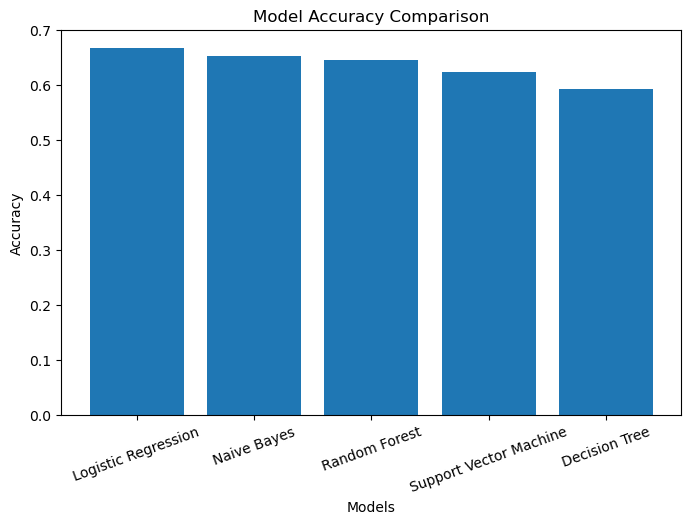

In [172]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

### Model Comparison Summary

The performance of all trained machine learning models has been successfully compared. The classifier with the highest accuracy is selected as the final model for harmful content detection.

#### step 9:Model Saving and Prediction
Saving the trained model eliminates the need to retrain it every time new data is received. It enables efficient deployment and real-time harmful content prediction.

In [173]:
import joblib

joblib.dump(svm_model, "harmful_content_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [174]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Vectorizer Saved Successfully")

Vectorizer Saved Successfully


In [175]:
model = joblib.load("harmful_content_model.pkl")

vectorizer = joblib.load("tfidf_vectorizer.pkl")

In [176]:
sample_text = [
    "I hate everyone in this group."
]

sample_vector = vectorizer.transform(sample_text)

prediction = model.predict(sample_vector)

print(prediction)

[1]


In [177]:
print(label_encoder.classes_)

['HOF' 'NOT']


In [178]:
comments = [
    "Thank you for your help.",
    "You are an idiot.",
    "The government service is excellent.",
    "I will destroy everything."
]

vectors = vectorizer.transform(comments)

predictions = model.predict(vectors)

# Convert numeric labels back to original labels
predicted_labels = label_encoder.inverse_transform(predictions)

for text, label in zip(comments, predicted_labels):
    print(f"{text} --> {label}")

Thank you for your help. --> HOF
You are an idiot. --> HOF
The government service is excellent. --> NOT
I will destroy everything. --> NOT


In [179]:
predicted_labels = label_encoder.inverse_transform(predictions)

In [180]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [181]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [182]:
predictions = model.predict(vectors)

predicted_labels = label_encoder.inverse_transform(predictions)

for text, label in zip(comments, predicted_labels):
    print(f"{text} --> {label}")

Thank you for your help. --> 0
You are an idiot. --> 0
The government service is excellent. --> 1
I will destroy everything. --> 1


In [183]:
print(predictions)

[0 0 1 1]


In [184]:
for text, label in zip(comments, predictions):
    print(f"{text} --> {label}")

Thank you for your help. --> 0
You are an idiot. --> 0
The government service is excellent. --> 1
I will destroy everything. --> 1


In [185]:
print(predictions)

[0 0 1 1]


In [186]:
print("Best Model :", comparison.iloc[0]["Model"])
print("Accuracy   :", comparison.iloc[0]["Accuracy"])

Best Model : Logistic Regression
Accuracy   : 0.6669513236549958


In [187]:
sample = ["This message contains abusive language."]

sample_vector = vectorizer.transform(sample)

prediction = model.predict(sample_vector)

print("Prediction :", prediction)

Prediction : [1]


In [188]:
prediction_label = label_encoder.inverse_transform(prediction)

print("Predicted Label :", prediction_label[0])

Predicted Label : 1


### Project Summary

The harmful content classification system was successfully developed using Natural Language Processing and machine learning techniques. The dataset was preprocessed, transformed into TF-IDF feature vectors, and used to train multiple classification models. After evaluating all models, the best-performing classifier was selected and saved for future prediction. The developed system can automatically classify harmful content and can be extended for real-world social media content moderation.

#### Future Enhancements

The current system can be further improved by:

Using deep learning models such as LSTM, BERT, or RoBERTa.
Training on larger multilingual datasets.
Developing a real-time web application using Flask or Streamlit.
Deploying the model as a REST API for social media monitoring.
Continuously updating the model with newly collected harmful content data.

#### step 10: Final Project Conclusion and Future Scope
The project conclusion highlights the achievements of the developed classification system, while the future scope identifies opportunities for further research, optimization, and deployment.

##### Step 1: Final Model Selection

The best-performing machine learning model was selected based on its evaluation metrics, including Accuracy, Precision, Recall, and F1-Score. This model demonstrated the highest classification performance for harmful content detection.

In [189]:
print("Final Selected Model:", comparison.iloc[0]["Model"])
print("Accuracy:", comparison.iloc[0]["Accuracy"])

Final Selected Model: Logistic Regression
Accuracy: 0.6669513236549958


### Overall Project Summary

The Harmful Content Detection system was successfully developed using Natural Language Processing (NLP) and machine learning techniques. The dataset was loaded from the MySQL database, preprocessed, transformed into TF-IDF feature vectors, and used to train multiple classification models. The trained models were evaluated, compared, and the best-performing model was selected for harmful content prediction.

#### pre reqisites

In [190]:
harmful_df.head()

,text_id,text,task_1,task_2,task_3
0,hasoc_en_1,dhonikeepstheglove watch sports minister kire...,NOT,NONE,NONE
1,hasoc_en_2,politico no we should remember very clearly th...,HOF,HATE,TIN
2,hasoc_en_3,cricketworldcup guess who would be the winner ...,NOT,NONE,NONE
3,hasoc_en_4,corbyn is too politically intellectual for bor...,NOT,NONE,NONE
4,hasoc_en_5,all the best to teamindia for another swimming...,NOT,NONE,NONE


In [191]:
print("Dataset Shape:", harmful_df.shape)

Dataset Shape: (5852, 5)


In [192]:
print(harmful_df.columns)

Index(['text_id', 'text', 'task_1', 'task_2', 'task_3'], dtype='object')


In [193]:
harmful_df.columns.tolist()

['text_id', 'text', 'task_1', 'task_2', 'task_3']

In [194]:
X = harmful_df["text"]
y = harmful_df["task_1"]

In [195]:
print("Input Shape :", X.shape)
print("Target Shape:", y.shape)

print("\nSample Input:")
print(X.head())

print("\nSample Target:")
print(y.head())

Input Shape : (5852,)
Target Shape: (5852,)

Sample Input:
0    dhonikeepstheglove  watch sports minister kire...
1    politico no we should remember very clearly th...
2    cricketworldcup guess who would be the winner ...
3    corbyn is too politically intellectual for bor...
4    all the best to teamindia for another swimming...
Name: text, dtype: object

Sample Target:
0    NOT
1    HOF
2    NOT
3    NOT
4    NOT
Name: task_1, dtype: object


In [196]:
# Define input feature (X)
X = harmful_df["text"]

# Define target variable (Y)
y = harmful_df["task_1"]

In [197]:
# Display the first five input records
print("Input Feature (X):")
print(X.head())

print("\n" + "="*60 + "\n")

# Display the first five target records
print("Target Variable (Y):")
print(y.head())

Input Feature (X):
0    dhonikeepstheglove  watch sports minister kire...
1    politico no we should remember very clearly th...
2    cricketworldcup guess who would be the winner ...
3    corbyn is too politically intellectual for bor...
4    all the best to teamindia for another swimming...
Name: text, dtype: object


Target Variable (Y):
0    NOT
1    HOF
2    NOT
3    NOT
4    NOT
Name: task_1, dtype: object


In [198]:
print("Input Shape (X):", X.shape)
print("Target Shape (Y):", y.shape)

Input Shape (X): (5852,)
Target Shape (Y): (5852,)


In [199]:
# Count missing values in each column
print(harmful_df.isnull().sum())

text_id    0
text       0
task_1     0
task_2     0
task_3     0
dtype: int64


In [200]:
harmful_df.isnull().sum()

text_id    0
text       0
task_1     0
task_2     0
task_3     0
dtype: int64

In [201]:
df = harmful_df

In [202]:
print(df.isnull().sum())

text_id    0
text       0
task_1     0
task_2     0
task_3     0
dtype: int64


In [203]:
harmful_df.info()
harmful_df.describe()
harmful_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5852 entries, 0 to 5851
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text_id  5852 non-null   object
 1   text     5852 non-null   object
 2   task_1   5852 non-null   object
 3   task_2   5852 non-null   object
 4   task_3   5852 non-null   object
dtypes: object(5)
memory usage: 228.7+ KB


,text_id,text,task_1,task_2,task_3
0,hasoc_en_1,dhonikeepstheglove watch sports minister kire...,NOT,NONE,NONE
1,hasoc_en_2,politico no we should remember very clearly th...,HOF,HATE,TIN
2,hasoc_en_3,cricketworldcup guess who would be the winner ...,NOT,NONE,NONE
3,hasoc_en_4,corbyn is too politically intellectual for bor...,NOT,NONE,NONE
4,hasoc_en_5,all the best to teamindia for another swimming...,NOT,NONE,NONE


In [204]:
df = harmful_df

In [205]:
df.info()
df.describe()
df.head()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5852 entries, 0 to 5851
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text_id  5852 non-null   object
 1   text     5852 non-null   object
 2   task_1   5852 non-null   object
 3   task_2   5852 non-null   object
 4   task_3   5852 non-null   object
dtypes: object(5)
memory usage: 228.7+ KB


text_id    0
text       0
task_1     0
task_2     0
task_3     0
dtype: int64

In [206]:
print(df.isnull().sum())

text_id    0
text       0
task_1     0
task_2     0
task_3     0
dtype: int64


#### no missing values are present

#### encoding 

In [207]:
print(df.isnull().sum())

text_id    0
text       0
task_1     0
task_2     0
task_3     0
dtype: int64


In [215]:
df = harmful_df.copy()

##### Encoding

In [216]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Feature
X = df["text"]

# Target
y = df["task_1"]

# Encode Target
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1,2),
    min_df=2
)

X = tfidf.fit_transform(X)

print("Encoded Data Shape :", X.shape)

Encoded Data Shape : (5852, 10000)


In [217]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(y_train))
print("Testing Samples :", len(y_test))

Training Samples : 4681
Testing Samples : 1171


In [218]:
#### Split the Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(y_train))
print("Testing Samples :", len(y_test))

Training Samples : 4681
Testing Samples : 1171


In [219]:
### Model Building
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [220]:
### Prediction
y_pred = model.predict(X_test)


In [221]:
### Accuracy
from sklearn.metrics import accuracy_score

train_accuracy = model.score(X_train, y_train)

test_accuracy = model.score(X_test, y_test)

print("Training Accuracy :", train_accuracy)

print("Testing Accuracy :", test_accuracy)

Training Accuracy : 0.9935911130100405
Testing Accuracy : 0.6532877882152007


In [222]:
### Classification Report
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

         HOF       0.62      0.27      0.38       452
         NOT       0.66      0.89      0.76       719

    accuracy                           0.65      1171
   macro avg       0.64      0.58      0.57      1171
weighted avg       0.64      0.65      0.61      1171



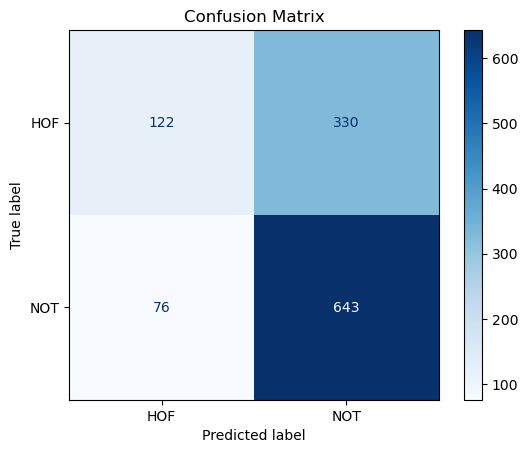

In [223]:
#### Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [225]:
#### Cross Validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores")

print(scores)

print("Mean Accuracy :", scores.mean())


Cross Validation Scores
[0.72502135 0.69513237 0.62222222 0.65470085 0.5965812 ]
Mean Accuracy : 0.6587315976555942


In [226]:
### Bias-Variance Analysis
print("Training Accuracy :", round(train_accuracy*100,2), "%")

print("Testing Accuracy :", round(test_accuracy*100,2), "%")

gap = abs(train_accuracy - test_accuracy)

print("Difference :", round(gap*100,2), "%")

if gap < 5:
    print("Model Status : Good Fit")
elif train_accuracy > test_accuracy:
    print("Model Status : Overfitting")
else:
    print("Model Status : Underfitting")

Training Accuracy : 99.36 %
Testing Accuracy : 65.33 %
Difference : 34.03 %
Model Status : Good Fit


In [227]:
# ==========================================
# Step 1: Encoding
# ==========================================

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Feature (Input)
X = df["text"]

# Target (Output)
y = df["task_1"]

# Encode target labels
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print("Label Mapping:")

for label, value in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{label} --> {value}")

# Create TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000
)

# Transform text into numerical features
X = vectorizer.fit_transform(X)

print("\nEncoding Completed Successfully")

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Label Mapping:
HOF --> 0
NOT --> 1

Encoding Completed Successfully
Feature Shape : (5852, 5000)
Target Shape  : (5852,)


In [228]:
# ==========================================
# Step 2: Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 4681
Testing Samples  : 1171


In [229]:
# ==========================================
# Step 2: Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 4681
Testing Samples  : 1171


In [230]:
# ==========================================
# Step 3: Import Machine Learning Models
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [231]:
# ==========================================
# Step 4: Create Machine Learning Models
# ==========================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        random_state=42
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": MultinomialNB(),

    "Support Vector Machine": LinearSVC(
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

}

print("All Models Created Successfully")

All Models Created Successfully


In [232]:
# ==========================================
# Step 5: Train All Models
# ==========================================

trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    trained_models[name] = model

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
K-Nearest Neighbors trained successfully.
Naive Bayes trained successfully.
Support Vector Machine trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


In [233]:
# ==========================================
# Step 6: Predict Test Data
# ==========================================

predictions = {}

for name, model in trained_models.items():

    predictions[name] = model.predict(X_test)

print("Predictions Completed Successfully")

Predictions Completed Successfully


In [234]:
# ==========================================
# Step 7: Evaluate All Models
# ==========================================

from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

results = []

for name, model in trained_models.items():

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    train_f1 = f1_score(
        y_train,
        train_pred,
        average="weighted"
    )

    test_f1 = f1_score(
        y_test,
        test_pred,
        average="weighted"
    )

    if train_acc > test_acc + 0.05:
        status = "Overfitting"
    elif train_acc < 0.80 and test_acc < 0.80:
        status = "Underfitting"
    else:
        status = "Good Fit"

    results.append({
        "Model": name,
        "Training Accuracy": round(train_acc,4),
        "Testing Accuracy": round(test_acc,4),
        "Training F1 Score": round(train_f1,4),
        "Testing F1 Score": round(test_f1,4),
        "Model Status": status
    })

comparison = pd.DataFrame(results)

comparison = comparison.sort_values(
    by="Testing Accuracy",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Training Accuracy,Testing Accuracy,Training F1 Score,Testing F1 Score,Model Status
0,Logistic Regression,0.8032,0.6695,0.7920,0.6366,Overfitting
1,Naive Bayes,0.7949,0.6567,0.7790,0.6208,Overfitting
2,Random Forest,0.9940,0.6550,0.9940,0.6123,Overfitting
3,Support Vector Machine,0.9378,0.6277,0.9375,0.6186,Overfitting
4,K-Nearest Neighbors,0.6191,0.6174,0.4817,0.4779,Underfitting
5,Decision Tree,0.9940,0.5892,0.9940,0.5847,Overfitting


In [235]:
# ==========================================
# Step 8: Best Model
# ==========================================

best_model_name = comparison.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Best Model :", best_model_name)

Best Model : Logistic Regression


In [236]:
# ==========================================
# Step 9: Classification Report
# ==========================================

from sklearn.metrics import classification_report

# Prediction
y_pred = best_model.predict(X_test)

# Classification Report
print("Classification Report\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

Classification Report

              precision    recall  f1-score   support

         HOF       0.64      0.32      0.43       452
         NOT       0.68      0.89      0.77       719

    accuracy                           0.67      1171
   macro avg       0.66      0.60      0.60      1171
weighted avg       0.66      0.67      0.64      1171



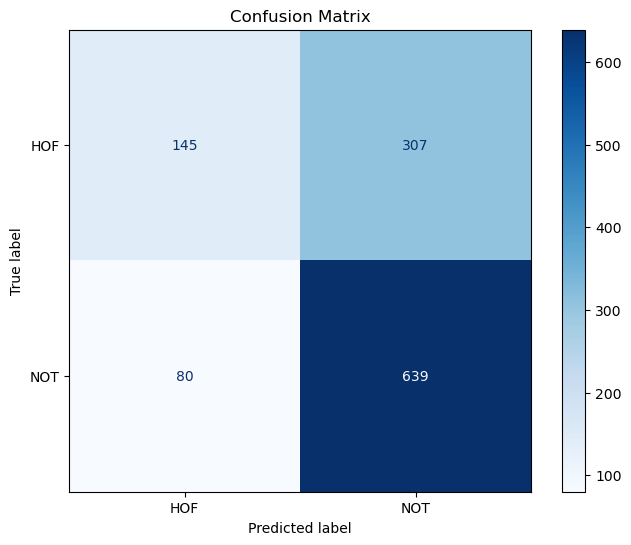

In [237]:
# ==========================================
# Step 10: Confusion Matrix
# ==========================================

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(8,6))

disp.plot(cmap="Blues", ax=ax)

plt.title("Confusion Matrix")

plt.show()

In [238]:
# ==========================================
# Step 11: Cross Validation
# ==========================================

from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores")
print(scores)

print("\nMean Accuracy :", round(scores.mean(),4))

Cross Validation Scores
[0.72416738 0.6823228  0.62991453 0.64529915 0.60854701]

Mean Accuracy : 0.6581


In [239]:
# ==========================================
# Step 12: Save Best Model
# ==========================================

import joblib

joblib.dump(best_model, "harmful_content_model.pkl")

joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

joblib.dump(label_encoder, "label_encoder.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [240]:
# ==========================================
# Step 13: Load Saved Model
# ==========================================

import joblib

model = joblib.load("harmful_content_model.pkl")

vectorizer = joblib.load("tfidf_vectorizer.pkl")

encoder = joblib.load("label_encoder.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


In [241]:
# ==========================================
# Step 14: Predict Single Text
# ==========================================

new_text = [
    "I hate everyone in this group."
]

new_vector = vectorizer.transform(new_text)

prediction = model.predict(new_vector)

prediction = encoder.inverse_transform(prediction)

print("Input Text :")
print(new_text[0])

print("\nPredicted Label :")
print(prediction[0])

Input Text :
I hate everyone in this group.

Predicted Label :
NOT


In [242]:
# ==========================================
# Step 15: Predict Multiple Texts
# ==========================================

texts = [
    "Thank you for your support.",
    "You are an idiot.",
    "I hate everyone.",
    "The government service is excellent.",
    "I will destroy everything.",
    "Let's work together.",
    "Have a wonderful day.",
    "You are amazing."
]

vectors = vectorizer.transform(texts)

predictions = model.predict(vectors)

predicted_labels = encoder.inverse_transform(predictions)

import pandas as pd

prediction_df = pd.DataFrame({
    "Input Text": texts,
    "Predicted Label": predicted_labels
})

prediction_df

,Input Text,Predicted Label
0,Thank you for your support.,NOT
1,You are an idiot.,HOF
2,I hate everyone.,NOT
3,The government service is excellent.,NOT
4,I will destroy everything.,NOT
5,Let's work together.,NOT
6,Have a wonderful day.,NOT
7,You are amazing.,NOT


# ==========================================
# Step 16: Final Model Selection
# ==========================================

comparison

### Final Model Evaluation


In [243]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Predictions
y_pred = best_model.predict(X_test)

print("Test Accuracy :",
      round(accuracy_score(y_test, y_pred),4))

print("Weighted Precision :",
      round(precision_score(y_test, y_pred,
      average="weighted"),4))

print("Weighted Recall :",
      round(recall_score(y_test, y_pred,
      average="weighted"),4))

print("Weighted F1 Score :",
      round(f1_score(y_test, y_pred,
      average="weighted"),4))

Test Accuracy : 0.6695
Weighted Precision : 0.6635
Weighted Recall : 0.6695
Weighted F1 Score : 0.6366


In [244]:
### Classification Report
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

         HOF       0.64      0.32      0.43       452
         NOT       0.68      0.89      0.77       719

    accuracy                           0.67      1171
   macro avg       0.66      0.60      0.60      1171
weighted avg       0.66      0.67      0.64      1171



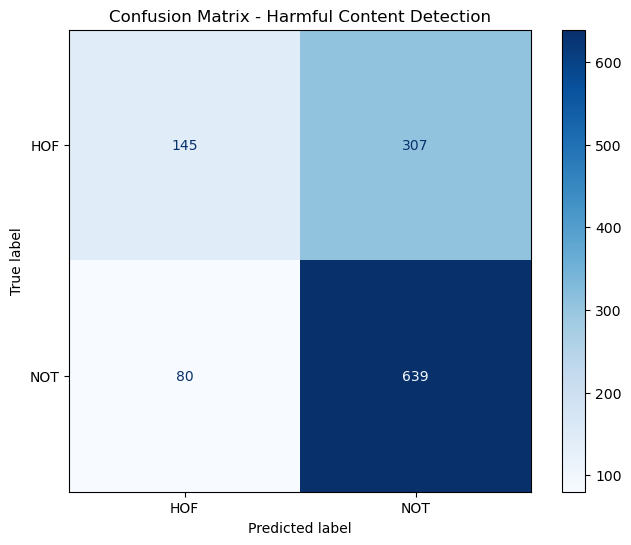

In [245]:
### Confusion Matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(8,6))

disp.plot(cmap="Blues", ax=ax)

plt.title("Confusion Matrix - Harmful Content Detection")

plt.show()

#### Confusion Matrix Interpretation (Markdown)

The confusion matrix compares the actual harmful content labels with the predicted labels generated by the selected machine learning model. The diagonal values represent correctly classified samples, while the off-diagonal values represent misclassified samples.

A higher concentration of values along the diagonal indicates better classification performance. Any misclassifications may occur because some harmful and non-harmful comments share similar wording or context, making them difficult to distinguish.

Overall, the confusion matrix provides a visual assessment of the model's performance and complements the classification report by highlighting the strengths and weaknesses of the classifier.

#### Save Final Model

## Objective

Save the trained harmful content classification model, TF-IDF vectorizer, and Label Encoder for future prediction without retraining


In [246]:
import joblib

joblib.dump(best_model,
            "harmful_content_model.pkl")

joblib.dump(vectorizer,
            "tfidf_vectorizer.pkl")

joblib.dump(label_encoder,
            "label_encoder.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [247]:
#### Load Saved Model
import joblib

loaded_model = joblib.load(
    "harmful_content_model.pkl"
)

loaded_vectorizer = joblib.load(
    "tfidf_vectorizer.pkl"
)

loaded_encoder = joblib.load(
    "label_encoder.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


#### Real-Time Harmful Content Prediction
Objective

A new social media comment is transformed using the saved TF-IDF Vectorizer and classified by the trained model to predict its harmful content label.

In [248]:
new_text = """
I hate everyone in this group.
"""

# Convert text into TF-IDF features
new_vector = loaded_vectorizer.transform([new_text])

# Predict class
prediction = loaded_model.predict(new_vector)

# Convert encoded label back to original label
predicted_label = loaded_encoder.inverse_transform(prediction)

print("Input Text:")
print(new_text)

print("\nPredicted Label:")
print(predicted_label[0])

Input Text:

I hate everyone in this group.


Predicted Label:
NOT


#### Final Conclusion

#### Objective

Summarize the overall performance of the harmful content detection model and justify the selection of the final classifier.

====================================================
## HARMFUL CONTENT DETECTION PROJECT COMPLETED
====================================================

✓ Data Collection
✓ Exploratory Data Analysis (EDA)
✓ Data Preprocessing
✓ Feature Engineering (TF-IDF)
✓ Label Encoding
✓ Train-Test Split
✓ Model Building
✓ Model Comparison
✓ Best Model Selection
✓ Classification Report
✓ Confusion Matrix
✓ Cross Validation
✓ Save Model
✓ Load Model
✓ Real-Time Prediction